<a href="https://colab.research.google.com/github/MtBalbine/PROJETO-1---ESTATISTICA-E-ANALISE-DE-DADOS/blob/main/VarQuantitativaCir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

Definição de arquivo

In [ ]:
arquivo = 'economia_circular.xlsx'
coluna = 'Taxa_Circularidade_percent'

Leitura de Planilha

In [ ]:
df=pd.read_excel(arquivo)
df

,Porte,Taxa_Circularidade_percent,Indice_Sustentabilidade
0,Pequeno,21.2,27.2
1,Médio,67.5,69.7
2,Médio,37.4,56.4
3,Médio,44.5,52.7
4,Médio,29.5,38.8
...,...,...,...
273,Médio,34.3,48.8
274,Médio,30.5,48.5
275,Pequeno,32.1,46.6
276,Pequeno,47.1,57.4


Extremidades da tabela

In [ ]:
valormin=df[coluna].min()
valormax=df[coluna].max()
print (valormin,valormax)

10.5 100.0


Definição de Classes


In [ ]:
classes = [10,20,30,40,50,60,70,80,90,100]
frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia.sort_index(ascending=True)

/tmp/ipykernel_4996/2838193740.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",61
"[30, 40)",78
"[40, 50)",36
"[50, 60)",25
"[60, 70)",16
"[70, 80)",14
"[80, 90)",7
"[90, 100)",8


Frequência Relativa

In [ ]:
Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
Freqpercentual.sort_index(ascending=True)

/tmp/ipykernel_4996/2202019940.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",22.68
"[30, 40)",29.00
"[40, 50)",13.38
"[50, 60)",9.29
"[60, 70)",5.95
"[70, 80)",5.20
"[80, 90)",2.60
"[90, 100)",2.97


Colunas de frequência acumulada e de frequência relativa acumulada


In [ ]:
#note que é necessário acumular a coluna da frequência com as classes ordenadas, isto é, usando sort_index
freqacum=np.cumsum(frequencia.sort_index())
freqacum




,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",85
"[30, 40)",163
"[40, 50)",199
"[50, 60)",224
"[60, 70)",240
"[70, 80)",254
"[80, 90)",261
"[90, 100)",269


In [ ]:
freqpercacum=np.cumsum(Freqpercentual.sort_index())
freqpercacum

,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",31.60
"[30, 40)",60.60
"[40, 50)",73.98
"[50, 60)",83.27
"[60, 70)",89.22
"[70, 80)",94.42
"[80, 90)",97.02
"[90, 100)",99.99


 Tabela Geral

In [ ]:
dist_freq = pd.DataFrame({'Frequência': frequencia,'Frequência Relativa (%)':Freqpercentual,'Frequência Acumulativa': freqacum,'Frequência Relativa Acumulativa (%)':freqpercacum})
display(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

,Frequência,Frequência Relativa (%),Frequência Acumulativa,Frequência Relativa Acumulativa (%)
Taxa_Circularidade_percent,,,,
"[10, 20)",24,8.92,24,8.92
"[20, 30)",61,22.68,85,31.60
"[30, 40)",78,29.00,163,60.60
"[40, 50)",36,13.38,199,73.98
"[50, 60)",25,9.29,224,83.27
"[60, 70)",16,5.95,240,89.22
"[70, 80)",14,5.20,254,94.42
"[80, 90)",7,2.60,261,97.02
"[90, 100)",8,2.97,269,99.99



      Variável:Taxa_Circularidade_percent
     *Limites superiores do intervalo de classes não incluídos


Histograma da Taxa de Circularidade


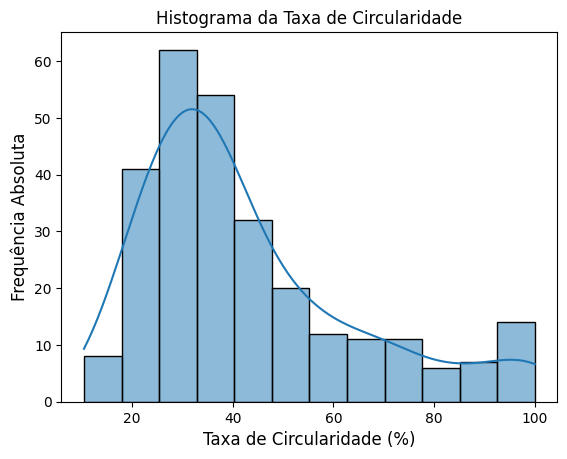

In [29]:
sns.histplot(data=df,x="Taxa_Circularidade_percent",kde=True)
plt.ylabel("Frequência Absoluta",size=12)
plt.xlabel("Taxa de Circularidade (%)",size=12)
plt.title('Histograma da Taxa de Circularidade') # Adiciona o título aqui
plt.show()

Calculo da méda, moda e mediana:

In [ ]:
#cálculo da Média.
df.Taxa_Circularidade_percent.mean()

np.float64(42.92122302158273)

In [ ]:
# cálculo da moda.
df.Taxa_Circularidade_percent.mode()

,Taxa_Circularidade_percent
0,100.0


In [ ]:
#cálculo da mediana.
df.Taxa_Circularidade_percent.median()

36.5